In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    classification_report
)
from collections import Counter

##### random number seed

In [2]:
n_number = 14420733
# n_number = rng

##### import adjusted data

In [3]:
df = pd.read_csv('rmpCapstoneAdjusted_69989.csv')
df

,Average Rating,Average Rating (Adjusted),Average Difficulty,Average Difficulty (Adjusted),Number of ratings,Received a “pepper”?,The proportion of students that said they would take the class again,The number of ratings coming from online classes,Male gender,Female,...,Hilarious (Normalized),Test heavy (Normalized),Graded by few things (Normalized),Amazing lectures (Normalized),Caring (Normalized),Extra credit (Normalized),Group projects (Normalized),Lecture heavy (Normalized),Total Number of Tags,Average Tags per Rating
0,5.0,4.284895,1.5,2.318731,2.0,0.0,NaN,0.0,0,1,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.500000,2,1.000000
1,3.2,3.460639,3.0,2.941951,4.0,0.0,NaN,0.0,1,0,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,12,3.000000
2,3.6,3.648037,3.5,3.353358,10.0,1.0,NaN,0.0,0,0,...,0.100000,0.0,0.0,0.000000,0.000000,0.0,0.100000,0.000000,22,2.200000
3,1.0,3.106119,5.0,3.398414,1.0,0.0,NaN,0.0,0,0,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0,0.000000
4,3.5,3.536979,3.3,3.247746,22.0,0.0,56.0,7.0,1,0,...,0.136364,0.0,0.0,0.000000,0.136364,0.0,0.045455,0.136364,53,2.409091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69984,3.9,3.860639,3.8,3.399094,4.0,1.0,NaN,0.0,0,1,...,0.000000,0.0,0.0,0.250000,0.250000,0.0,0.000000,0.000000,9,2.250000
69985,2.5,3.284895,2.5,2.718731,2.0,0.0,NaN,0.0,0,0,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,4,2.000000
69986,4.5,4.084895,2.0,2.518731,2.0,0.0,NaN,0.0,1,0,...,0.000000,0.0,0.0,0.000000,0.500000,0.0,0.000000,0.000000,6,3.000000
69987,5.0,4.602719,1.7,2.088184,6.0,1.0,100.0,2.0,1,0,...,0.666667,0.0,0.0,0.166667,0.000000,0.0,0.000000,0.000000,14,2.333333


In [4]:
df.columns

Index(['Average Rating', 'Average Rating (Adjusted)', 'Average Difficulty',
       'Average Difficulty (Adjusted)', 'Number of ratings',
       'Received a “pepper”?',
       'The proportion of students that said they would take the class again',
       'The number of ratings coming from online classes', 'Male gender',
       'Female', 'Major/Field', 'University', 'US State', 'Tough grader',
       'Good feedback', 'Respected', 'Lots to read', 'Participation matters',
       'Don’t skip class or you will not pass', 'Lots of homework',
       'Inspirational', 'Pop quizzes!', 'Accessible', 'So many papers',
       'Clear grading', 'Hilarious', 'Test heavy', 'Graded by few things',
       'Amazing lectures', 'Caring', 'Extra credit', 'Group projects',
       'Lecture heavy', 'Tough grader (Normalized)',
       'Good feedback (Normalized)', 'Respected (Normalized)',
       'Lots to read (Normalized)', 'Participation matters (Normalized)',
       'Don’t skip class or you will not pass (Norm

##### cope missing value

In [5]:
missing_values = df.isna().sum()
# print(missing_values)
df = df.copy()
# df_cleaned = df.dropna()
df_cleaned = df.fillna(df.mean())
#df['The proportion of students that said they would take the class again'] = df['The proportion of students that said they would take the class again'].fillna(0)
missing_values = df_cleaned.isna().sum()
print(missing_values)
print(len(df_cleaned))

Average Rating                                                          0
Average Rating (Adjusted)                                               0
Average Difficulty                                                      0
Average Difficulty (Adjusted)                                           0
Number of ratings                                                       0
Received a “pepper”?                                                    0
The proportion of students that said they would take the class again    0
The number of ratings coming from online classes                        0
Male gender                                                             0
Female                                                                  0
Major/Field                                                             0
University                                                              0
US State                                                                0
Tough grader                          

### Q7 - Build a regression model predicting average rating from all numerical predictors 
(the ones in the rmpCapstoneNum.csv) file.Make sure to include the R2and RMSE of this model. Which of these factors is most strongly predictive of average rating? Hint: Make sure to address collinearity concern

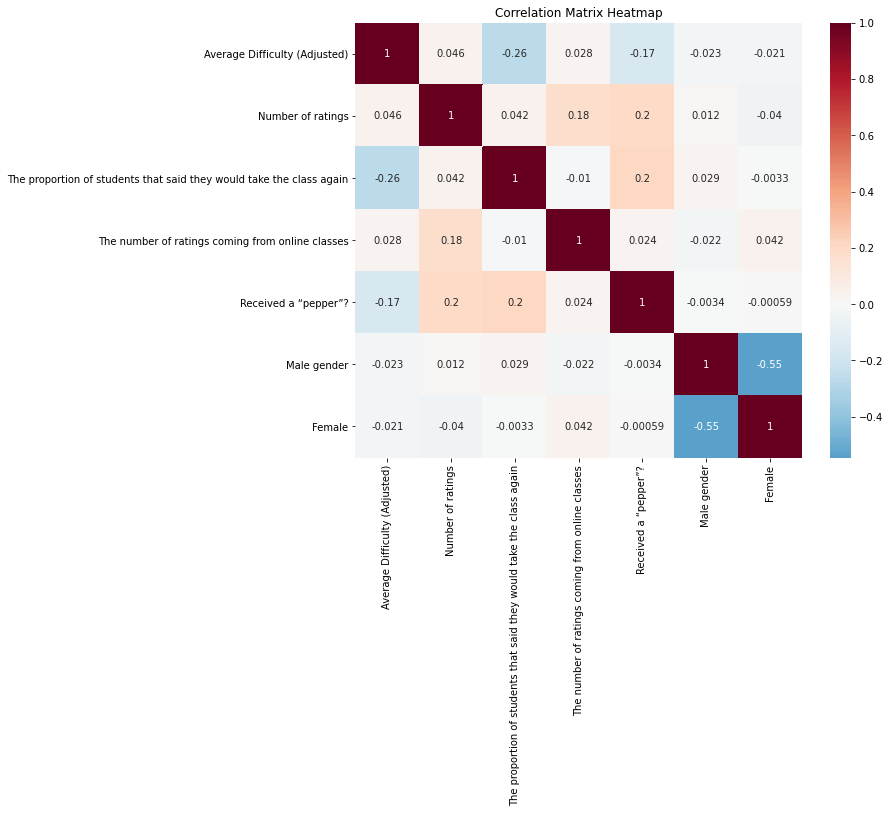

,Average Difficulty (Adjusted),Number of ratings,The proportion of students that said they would take the class again,The number of ratings coming from online classes,Received a “pepper”?,Male gender,Female
0,2.318731,2.0,76.417105,0.0,0.0,0,1
1,2.941951,4.0,76.417105,0.0,0.0,1,0
2,3.353358,10.0,76.417105,0.0,1.0,0,0
3,3.398414,1.0,76.417105,0.0,0.0,0,0
4,3.247746,22.0,56.000000,7.0,0.0,1,0
...,...,...,...,...,...,...,...
69984,3.399094,4.0,76.417105,0.0,1.0,0,1
69985,2.718731,2.0,76.417105,0.0,0.0,0,0
69986,2.518731,2.0,76.417105,0.0,0.0,1,0
69987,2.088184,6.0,100.000000,2.0,1.0,1,0


In [6]:
# Step 1: specify X and y
y =  df_cleaned['Average Rating (Adjusted)']
X = df_cleaned[['Average Difficulty (Adjusted)', 
       'Number of ratings',
       'The proportion of students that said they would take the class again',
       'The number of ratings coming from online classes', 
       'Received a “pepper”?',
       'Male gender',
       'Female'
      ]]

# check correlation
correlation_matrix = X.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="RdBu_r", center=0, xticklabels=True, yticklabels=True)
plt.title('Correlation Matrix Heatmap')
plt.show()
X

In [7]:
# check missing values
missing_values = X.isna().sum()
print(missing_values)
len(X)

Average Difficulty (Adjusted)                                           0
Number of ratings                                                       0
The proportion of students that said they would take the class again    0
The number of ratings coming from online classes                        0
Received a “pepper”?                                                    0
Male gender                                                             0
Female                                                                  0
dtype: int64


69989

Best Alpha (Ridge): 0.0
Lowest Validation MSE: 0.1604104316897593


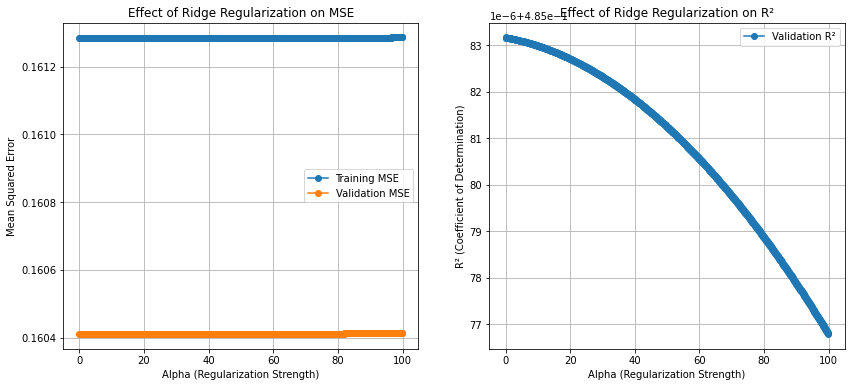

In [8]:
# Step 2: Train-Test Split (80-20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=n_number)

# Step 3: Standardize the features (scale to zero mean and unit variance) - only scale continous variable
X_train_continuous = X_train.iloc[:, :4]  
X_train_others = X_train.iloc[:, 4:]     

X_val_continuous = X_val.iloc[:, :4]     
X_val_others = X_val.iloc[:, 4:]        

scaler = StandardScaler()
X_train_continuous_scaled = scaler.fit_transform(X_train_continuous)
X_val_continuous_scaled = scaler.transform(X_val_continuous)

# Combine the scaled continuous columns with the rest (dummy variables)
X_train_scaled = np.hstack([X_train_continuous_scaled, X_train_others.values])
X_val_scaled = np.hstack([X_val_continuous_scaled, X_val_others.values])

# Step 4: Train a lasso Regression model with different alpha values
# alphas = np.logspace(-3, 1, 100)  # Logarithmic range for alpha
alphas = np.arange(0,100,0.1)
ridge_train_mse = []
ridge_val_mse = []
ridge_train_r2 = []  
ridge_val_r2 = []    

for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)  # Use Ridge Regression 
    ridge_model.fit(X_train_scaled, y_train)
    
    # Predict on training and validation data
    y_train_pred_ridge = ridge_model.predict(X_train_scaled)
    y_val_pred_ridge = ridge_model.predict(X_val_scaled)
    
    # Compute MSE for training and validation
    ridge_train_mse.append(mean_squared_error(y_train, y_train_pred_ridge))
    ridge_val_mse.append(mean_squared_error(y_val, y_val_pred_ridge))
    ridge_train_r2.append(r2_score(y_train, y_train_pred_ridge))
    ridge_val_r2.append(r2_score(y_val, y_val_pred_ridge))

# Find the alpha with the lowest validation MSE
best_alpha_ridge = alphas[np.argmin(ridge_val_mse)]
print(f"Best Alpha (Ridge): {best_alpha_ridge}")
print(f"Lowest Validation MSE: {min(ridge_val_mse)}")

# Step 4: Plot Training and Validation MSE
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(alphas, ridge_train_mse, label='Training MSE', marker='o')
plt.plot(alphas, ridge_val_mse, label='Validation MSE', marker='o')
# plt.xscale('log')  # Log scale for alpha
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Mean Squared Error')
plt.title('Effect of Ridge Regularization on MSE')
plt.legend()
plt.grid(True)

# Plot R²
plt.subplot(1, 2, 2)
plt.plot(alphas, ridge_val_r2, label='Validation R²', marker='o')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R² (Coefficient of Determination)')
plt.title('Effect of Ridge Regularization on R²')

plt.legend()
plt.grid(True)
plt.show()

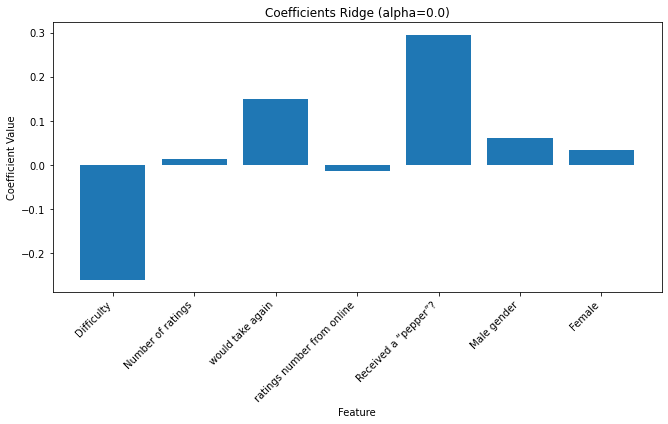

Final Validation R²: 0.48508317230553977
Feature with the highest coefficient (absolute value): Received a “pepper”?
Value of the highest coefficient: 0.29537990300599387


In [9]:
# Step 7: Visualize the betas (coefficients) from models

ridge_model = Ridge(alpha=best_alpha_ridge)
ridge_model.fit(X_train_scaled, y_train)
betas_ridge = ridge_model.coef_

# Plot the coefficients (betas) for all models
plt.figure(figsize=(18, 6))

feature_name = ['Difficulty', 
       'Number of ratings',
       'would take again',
       'ratings number from online', 
       'Received a “pepper”?',
       'Male gender',
       'Female'
      ]

# Ridge Regression Coefficients (for best alpha)
plt.subplot(1, 2, 1)
plt.bar(feature_name, betas_ridge)
plt.title(f'Coefficients Ridge (alpha={best_alpha_ridge})')
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

final_train_r2 = r2_score(y_train, ridge_model.predict(X_train_scaled))
final_val_r2 = r2_score(y_val, ridge_model.predict(X_val_scaled))

print(f"Final Validation R²: {final_val_r2}")

highest_beta_index = np.argmax(np.abs(betas_ridge))
highest_beta_feature = feature_name[highest_beta_index]
highest_beta_value = betas_ridge[highest_beta_index]

print(f"Feature with the highest coefficient (absolute value): {highest_beta_feature}")
print(f"Value of the highest coefficient: {highest_beta_value}")


### Q8 - Build a regression model predicting average ratings from all tags
(the ones in the rmpCapstoneTags.csv) file. Make sure to include the R2and RMSE of this model. Which of these tags is most strongly predictive of average rating? Hint: Make sure to address collinearity concerns. Also comment on how this model compares to the previous one

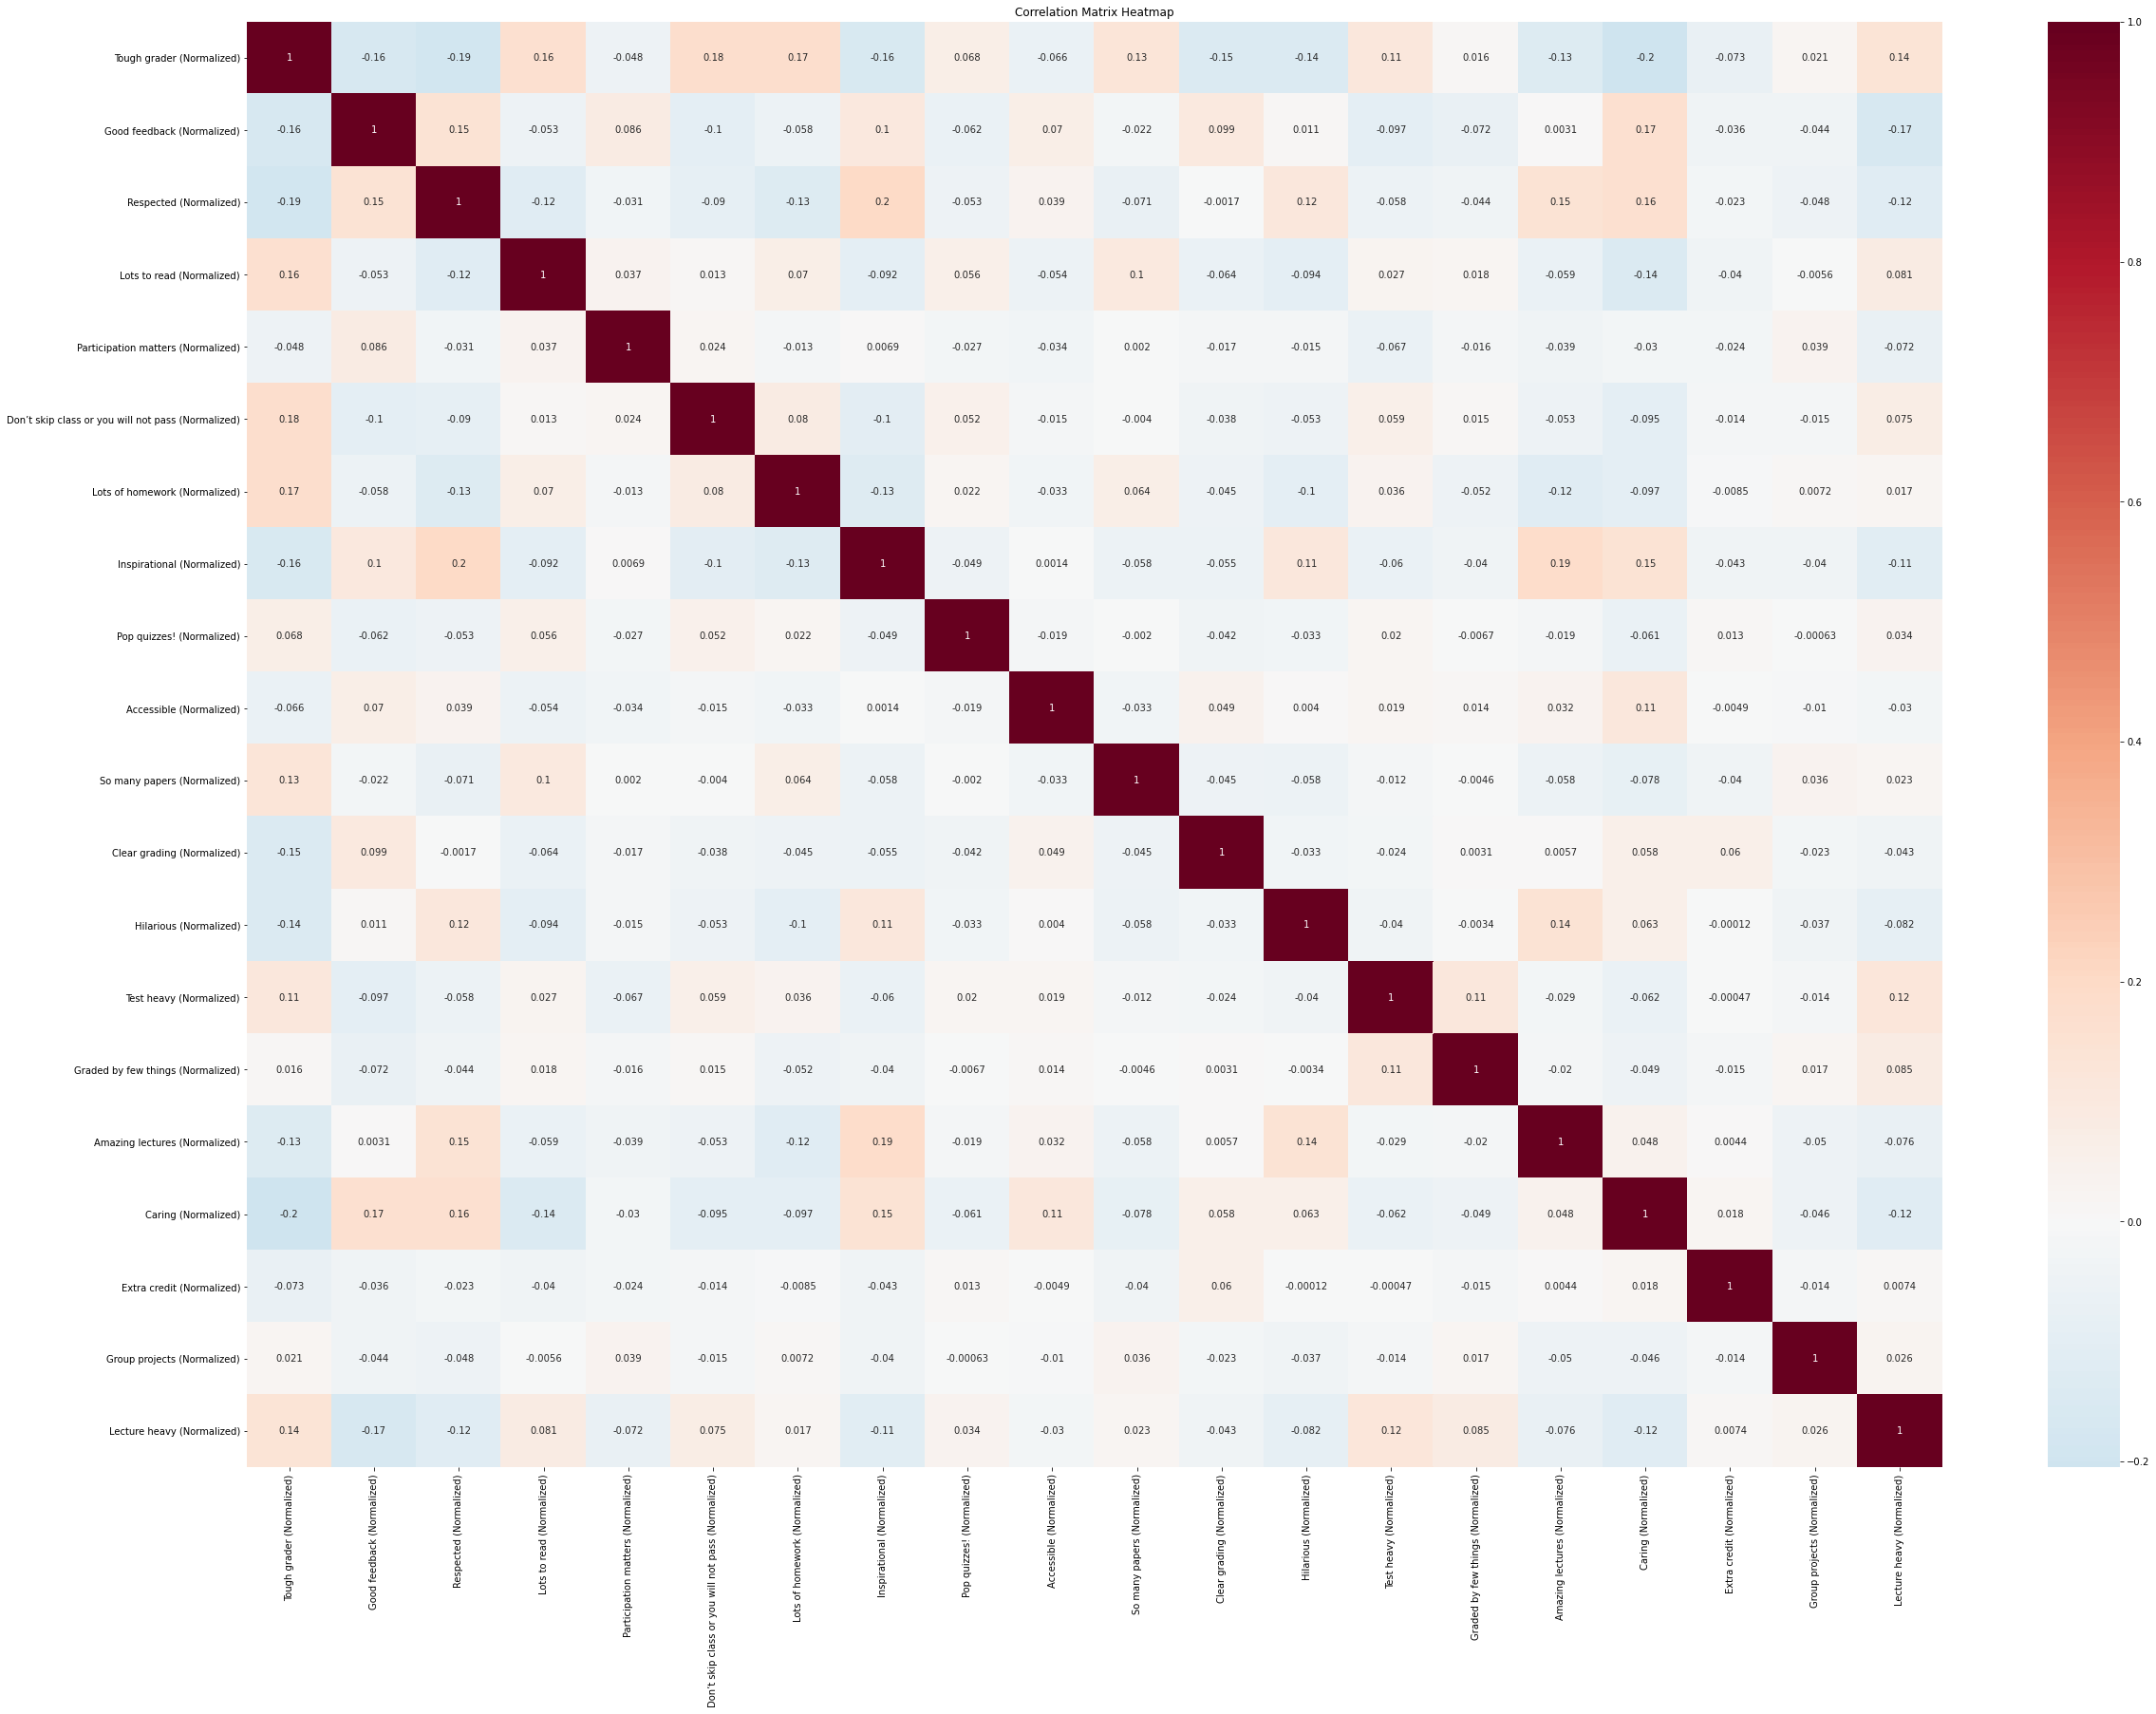

,Tough grader (Normalized),Good feedback (Normalized),Respected (Normalized),Lots to read (Normalized),Participation matters (Normalized),Don’t skip class or you will not pass (Normalized),Lots of homework (Normalized),Inspirational (Normalized),Pop quizzes! (Normalized),Accessible (Normalized),So many papers (Normalized),Clear grading (Normalized),Hilarious (Normalized),Test heavy (Normalized),Graded by few things (Normalized),Amazing lectures (Normalized),Caring (Normalized),Extra credit (Normalized),Group projects (Normalized),Lecture heavy (Normalized)
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.500000
1,0.500000,0.250000,0.500000,0.250000,0.000000,1.000000,0.500000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
2,0.600000,0.300000,0.000000,0.000000,0.200000,0.400000,0.200000,0.100000,0.0,0.000000,0.0,0.200000,0.100000,0.0,0.0,0.000000,0.000000,0.0,0.100000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
4,0.363636,0.590909,0.045455,0.136364,0.090909,0.136364,0.090909,0.045455,0.0,0.136364,0.0,0.318182,0.136364,0.0,0.0,0.000000,0.136364,0.0,0.045455,0.136364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69984,0.500000,0.000000,0.000000,0.750000,0.000000,0.250000,0.000000,0.250000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.250000,0.250000,0.0,0.000000,0.000000
69985,0.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.500000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
69986,0.500000,0.500000,0.000000,0.000000,0.500000,0.500000,0.000000,0.000000,0.0,0.000000,0.0,0.500000,0.000000,0.0,0.0,0.000000,0.500000,0.0,0.000000,0.000000
69987,0.000000,0.500000,0.166667,0.166667,0.333333,0.166667,0.000000,0.000000,0.0,0.166667,0.0,0.000000,0.666667,0.0,0.0,0.166667,0.000000,0.0,0.000000,0.000000


In [10]:
y2 =  df_cleaned['Average Rating (Adjusted)']
X2 = df_cleaned[[ 'Tough grader (Normalized)',
       'Good feedback (Normalized)', 'Respected (Normalized)',
       'Lots to read (Normalized)', 'Participation matters (Normalized)',
       'Don’t skip class or you will not pass (Normalized)',
       'Lots of homework (Normalized)', 'Inspirational (Normalized)',
       'Pop quizzes! (Normalized)', 'Accessible (Normalized)',
       'So many papers (Normalized)', 'Clear grading (Normalized)',
       'Hilarious (Normalized)', 'Test heavy (Normalized)',
       'Graded by few things (Normalized)', 'Amazing lectures (Normalized)',
       'Caring (Normalized)', 'Extra credit (Normalized)',
       'Group projects (Normalized)', 'Lecture heavy (Normalized)'
      ]]

#check correlation
correlation_matrix2 = X2.corr()

plt.figure(figsize=(40, 28))
sns.heatmap(correlation_matrix2, annot=True, cmap="RdBu_r", center=0, xticklabels=True, yticklabels=True)
plt.title('Correlation Matrix Heatmap')
plt.show()
X2

In [11]:
# check missing values
missing_values2 = X2.isna().sum()
print(missing_values2)
len(X2)

Tough grader (Normalized)                             0
Good feedback (Normalized)                            0
Respected (Normalized)                                0
Lots to read (Normalized)                             0
Participation matters (Normalized)                    0
Don’t skip class or you will not pass (Normalized)    0
Lots of homework (Normalized)                         0
Inspirational (Normalized)                            0
Pop quizzes! (Normalized)                             0
Accessible (Normalized)                               0
So many papers (Normalized)                           0
Clear grading (Normalized)                            0
Hilarious (Normalized)                                0
Test heavy (Normalized)                               0
Graded by few things (Normalized)                     0
Amazing lectures (Normalized)                         0
Caring (Normalized)                                   0
Extra credit (Normalized)                       

69989

Best Alpha (Ridge): 0.0
Lowest Validation MSE: 0.15749257464511304


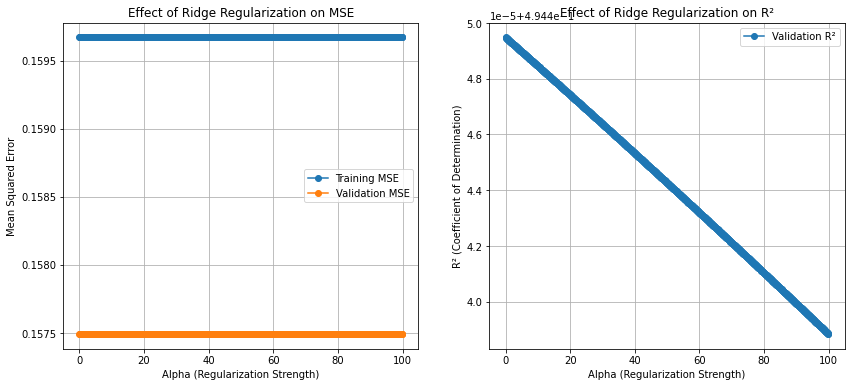

In [12]:
# Step 2: Train-Test Split (80-20)
X2_train, X2_val, y2_train, y2_val = train_test_split(X2, y2, test_size=0.2, random_state=n_number)

# Step 3: Standardize the features (scale to zero mean and unit variance)  
scaler = StandardScaler()
X2_train_scaled = scaler.fit_transform(X2_train)
X2_val_scaled = scaler.transform(X2_val)

# Step 4: Train a lasso Regression model with different alpha values
alphas = np.arange(0,100,0.1)
ridge_train_mse_2 = []
ridge_val_mse_2 = []
ridge_train_r2_2 = []  # Store R² for training
ridge_val_r2_2 = []    # Store R² for validation

for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)  # Use Ridge Regression instead of Lasso
    ridge_model.fit(X2_train_scaled, y2_train)
    
    # Predict on training and validation data
    y_train_pred_ridge_2 = ridge_model.predict(X2_train_scaled)
    y_val_pred_ridge_2 = ridge_model.predict(X2_val_scaled)
    
    # Compute MSE for training and validation
    ridge_train_mse_2.append(mean_squared_error(y2_train, y_train_pred_ridge_2))
    ridge_val_mse_2.append(mean_squared_error(y2_val, y_val_pred_ridge_2))
    ridge_train_r2_2.append(r2_score(y2_train, y_train_pred_ridge_2))
    ridge_val_r2_2.append(r2_score(y2_val, y_val_pred_ridge_2))

# Find the alpha with the lowest validation MSE
best_alpha_ridge_2 = alphas[np.argmin(ridge_val_mse_2)]
print(f"Best Alpha (Ridge): {best_alpha_ridge_2}")
print(f"Lowest Validation MSE: {min(ridge_val_mse_2)}")

# Step 4: Plot Training and Validation MSE
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(alphas, ridge_train_mse_2, label='Training MSE', marker='o')
plt.plot(alphas, ridge_val_mse_2, label='Validation MSE', marker='o')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Mean Squared Error')
plt.title('Effect of Ridge Regularization on MSE')
plt.legend()
plt.grid(True)

# Plot R²
plt.subplot(1, 2, 2)
# plt.plot(alphas, ridge_train_r2, label='Training R²', marker='o')
plt.plot(alphas, ridge_val_r2_2, label='Validation R²', marker='o')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R² (Coefficient of Determination)')
plt.title('Effect of Ridge Regularization on R²')

plt.legend()
plt.grid(True)
plt.show()

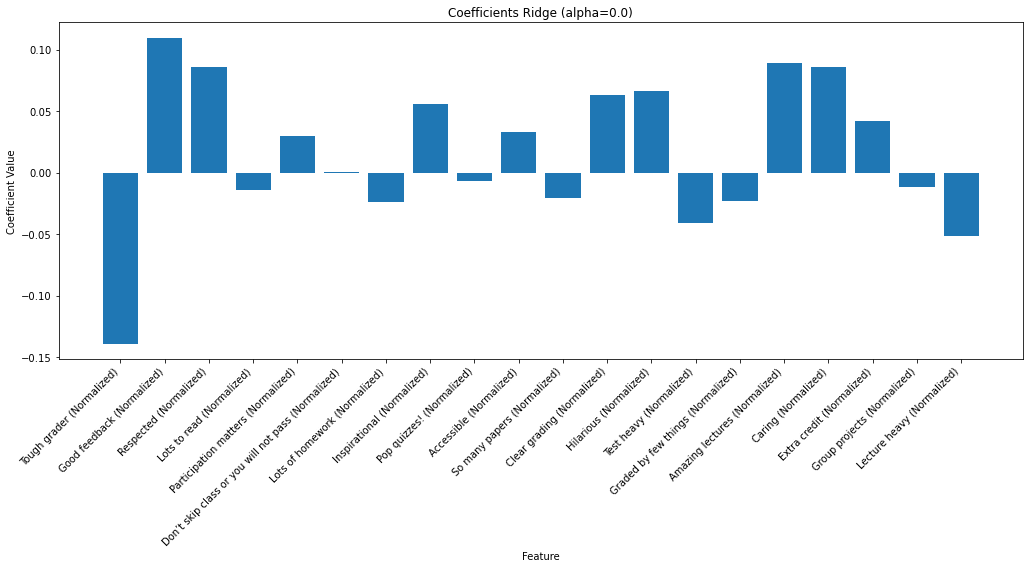

Final Validation R²: 0.4944494814493303
Feature with the highest coefficient (absolute value): Tough grader (Normalized)
Value of the highest coefficient: -0.13900243643586083


In [13]:
# Step 7: Visualize the betas (coefficients) 

ridge_model = Ridge(alpha=best_alpha_ridge_2)
ridge_model.fit(X2_train_scaled, y2_train)
betas_ridge = ridge_model.coef_

# Plot the coefficients (betas) for all models
plt.figure(figsize=(28, 8))

feature_name = [ 'Tough grader (Normalized)',
       'Good feedback (Normalized)', 'Respected (Normalized)',
       'Lots to read (Normalized)', 'Participation matters (Normalized)',
       'Don’t skip class or you will not pass (Normalized)',
       'Lots of homework (Normalized)', 'Inspirational (Normalized)',
       'Pop quizzes! (Normalized)', 'Accessible (Normalized)',
       'So many papers (Normalized)', 'Clear grading (Normalized)',
       'Hilarious (Normalized)', 'Test heavy (Normalized)',
       'Graded by few things (Normalized)', 'Amazing lectures (Normalized)',
       'Caring (Normalized)', 'Extra credit (Normalized)',
       'Group projects (Normalized)', 'Lecture heavy (Normalized)'
      ]

# Ridge Regression Coefficients (for best alpha)
plt.subplot(1, 2, 1)
plt.bar(feature_name, betas_ridge)
plt.title(f'Coefficients Ridge (alpha={best_alpha_ridge})')
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')


plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

final_train_r2 = r2_score(y2_train, ridge_model.predict(X2_train_scaled))
final_val_r2 = r2_score(y2_val, ridge_model.predict(X2_val_scaled))

print(f"Final Validation R²: {final_val_r2}")

highest_beta_index = np.argmax(np.abs(betas_ridge))
highest_beta_feature = feature_name[highest_beta_index]
highest_beta_value = betas_ridge[highest_beta_index]

print(f"Feature with the highest coefficient (absolute value): {highest_beta_feature}")
print(f"Value of the highest coefficient: {highest_beta_value}")


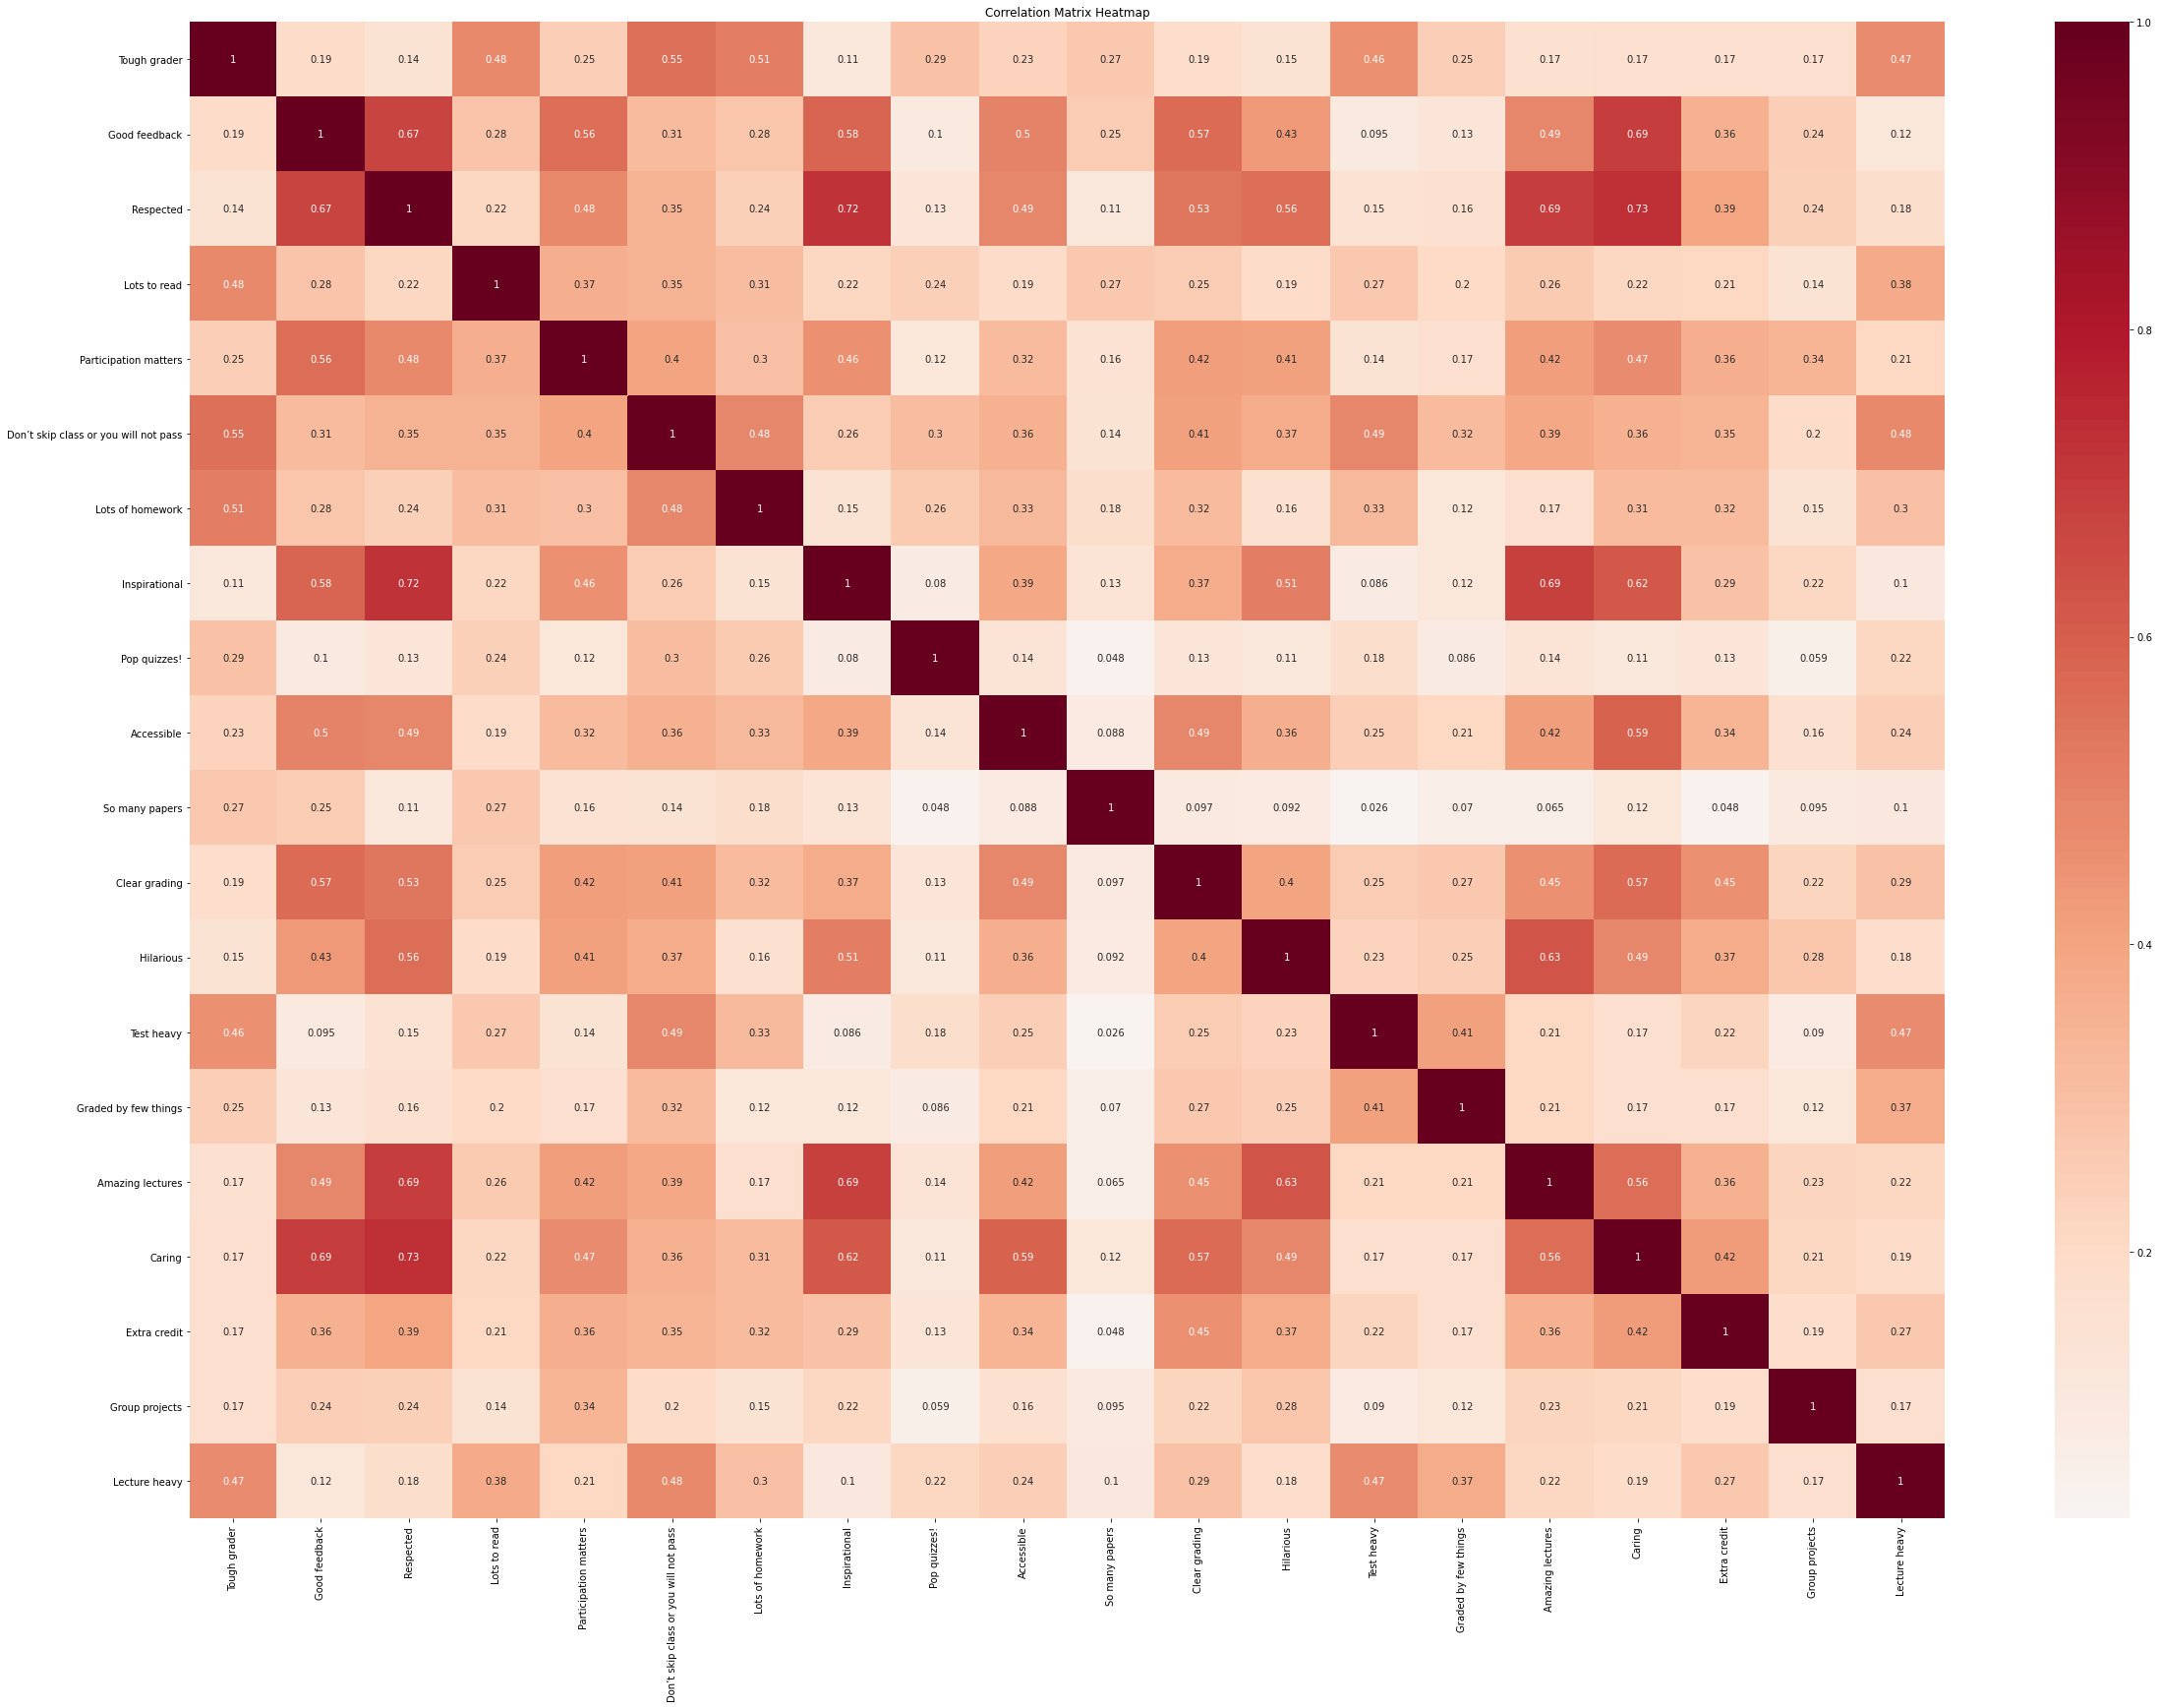

In [14]:
# test the meodel with original unnormalized tag data(just for comaprision)
X2_origin = df_cleaned[['Tough grader',
       'Good feedback', 'Respected', 'Lots to read', 'Participation matters',
       'Don’t skip class or you will not pass', 'Lots of homework',
       'Inspirational', 'Pop quizzes!', 'Accessible', 'So many papers',
       'Clear grading', 'Hilarious', 'Test heavy', 'Graded by few things',
       'Amazing lectures', 'Caring', 'Extra credit', 'Group projects',
       'Lecture heavy'
      ]]
correlation_matrix2_origin = X2_origin.corr()

plt.figure(figsize=(40, 28))
sns.heatmap(correlation_matrix2_origin, annot=True, cmap="RdBu_r", center=0, xticklabels=True, yticklabels=True)
plt.title('Correlation Matrix Heatmap')
plt.show()

Best Alpha (Ridge): 2499.5
Lowest Validation MSE: 0.2027377483434572


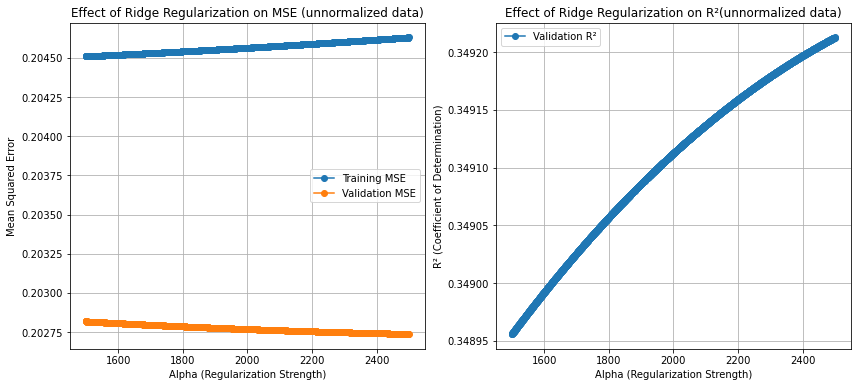

In [15]:
# Step 2: Train-Test Split (80-20)
X2_train, X2_val, y2_train, y2_val = train_test_split(X2_origin, y2, test_size=0.2, random_state=n_number)

# Step 3: Standardize the features (scale to zero mean and unit variance) - only scale continous variable      

scaler = StandardScaler()
X2_train_scaled = scaler.fit_transform(X2_train)
X2_val_scaled = scaler.transform(X2_val)

# Step 4: Train a lasso Regression model with different alpha values
# alphas = np.logspace(-3, 1, 100)  # Logarithmic range for alpha
alphas = np.arange(1500,5000,1)
ridge_train_mse_2 = []
ridge_val_mse_2 = []
ridge_train_r2_2 = []  # Store R² for training
ridge_val_r2_2 = []    # Store R² for validation

for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)  # Use Ridge Regression instead of Lasso
    ridge_model.fit(X2_train_scaled, y2_train)
    
    # Predict on training and validation data
    y_train_pred_ridge_2 = ridge_model.predict(X2_train_scaled)
    y_val_pred_ridge_2 = ridge_model.predict(X2_val_scaled)
    
    # Compute MSE for training and validation
    ridge_train_mse_2.append(mean_squared_error(y2_train, y_train_pred_ridge_2))
    ridge_val_mse_2.append(mean_squared_error(y2_val, y_val_pred_ridge_2))
    ridge_train_r2_2.append(r2_score(y2_train, y_train_pred_ridge_2))
    ridge_val_r2_2.append(r2_score(y2_val, y_val_pred_ridge_2))

# Find the alpha with the lowest validation MSE
best_alpha_ridge_2 = alphas[np.argmin(ridge_val_mse_2)]
print(f"Best Alpha (Ridge): {best_alpha_ridge_2}")
print(f"Lowest Validation MSE: {min(ridge_val_mse_2)}")

# Step 4: Plot Training and Validation MSE
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(alphas, ridge_train_mse_2, label='Training MSE', marker='o')
plt.plot(alphas, ridge_val_mse_2, label='Validation MSE', marker='o')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Mean Squared Error')
plt.title('Effect of Ridge Regularization on MSE (unnormalized data)')
plt.legend()
plt.grid(True)

# Plot R²
plt.subplot(1, 2, 2)
# plt.plot(alphas, ridge_train_r2, label='Training R²', marker='o')
plt.plot(alphas, ridge_val_r2_2, label='Validation R²', marker='o')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R² (Coefficient of Determination)')
plt.title('Effect of Ridge Regularization on R²(unnormalized data)')

plt.legend()
plt.grid(True)
plt.show()

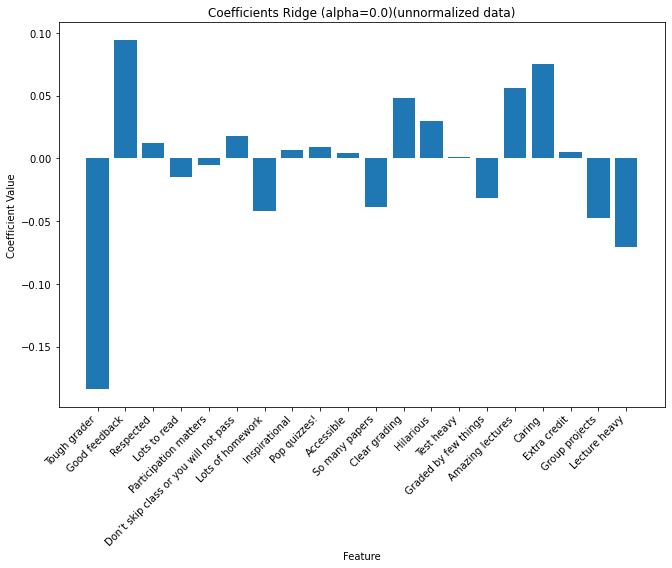

Final Validation R²: 0.3492126594807031
Feature with the highest coefficient (absolute value): Tough grader
Value of the highest coefficient: -0.18394483371643544


In [16]:
# Step 7: Visualize the betas (coefficients) from all models

# Ridge model coefficients (for the best alpha, e.g., alpha=1.0)
ridge_model = Ridge(alpha=best_alpha_ridge_2)
ridge_model.fit(X2_train_scaled, y2_train)
betas_ridge = ridge_model.coef_

# Plot the coefficients (betas) for all models
plt.figure(figsize=(18, 8))

feature_name = ['Tough grader',
       'Good feedback', 'Respected', 'Lots to read', 'Participation matters',
       'Don’t skip class or you will not pass', 'Lots of homework',
       'Inspirational', 'Pop quizzes!', 'Accessible', 'So many papers',
       'Clear grading', 'Hilarious', 'Test heavy', 'Graded by few things',
       'Amazing lectures', 'Caring', 'Extra credit', 'Group projects',
       'Lecture heavy'
      ]
# Ridge Regression Coefficients (for best alpha)
plt.subplot(1, 2, 1)
plt.bar(feature_name, betas_ridge)
plt.title(f'Coefficients Ridge (alpha={best_alpha_ridge})(unnormalized data)')
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')


plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

final_train_r2 = r2_score(y2_train, ridge_model.predict(X2_train_scaled))
final_val_r2 = r2_score(y2_val, ridge_model.predict(X2_val_scaled))

print(f"Final Validation R²: {final_val_r2}")

highest_beta_index = np.argmax(np.abs(betas_ridge))
highest_beta_feature = feature_name[highest_beta_index]
highest_beta_value = betas_ridge[highest_beta_index]

print(f"Feature with the highest coefficient (absolute value): {highest_beta_feature}")
print(f"Value of the highest coefficient: {highest_beta_value}")

### Q9 - Build a regression model predicting average difficulty from all tags
(the ones in the rmpCapstoneTags.csv) file. Make sure to include the R2and RMSE of this model. Which of these tags is most strongly predictive of average rating? Hint: Make sure to address collinearity concerns. Also comment on how this model compares to the previous one

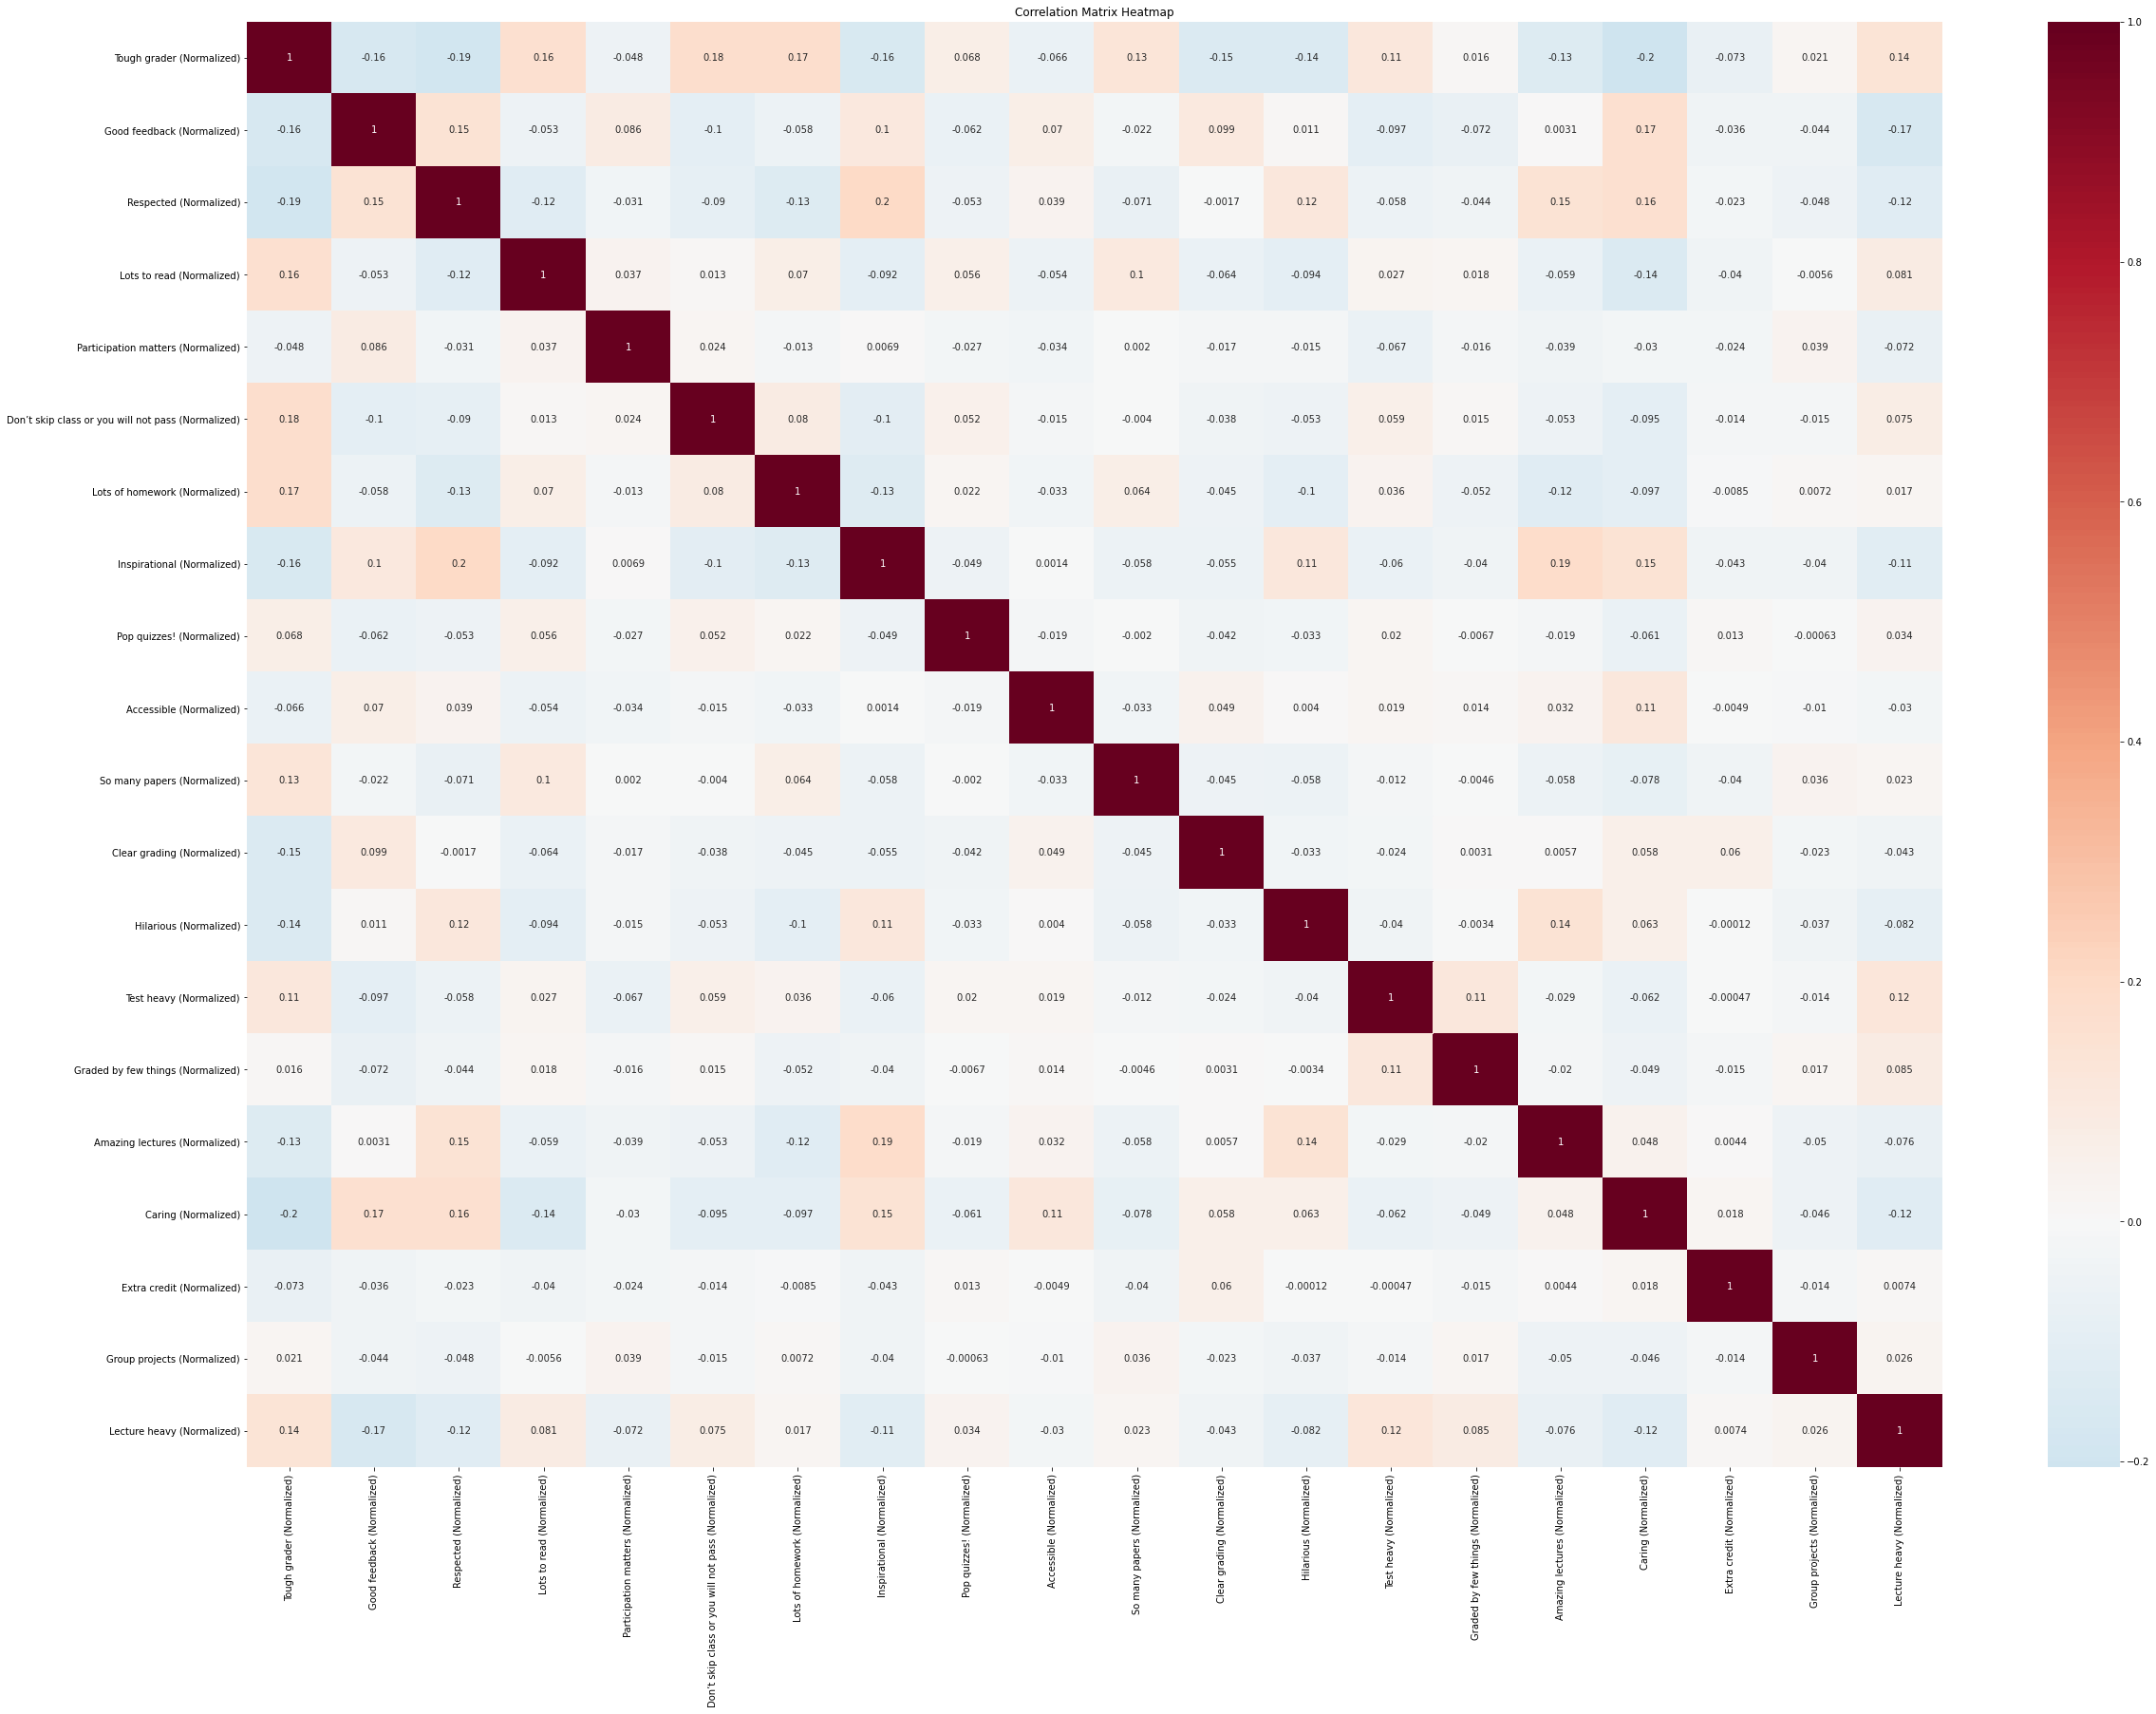

,Tough grader (Normalized),Good feedback (Normalized),Respected (Normalized),Lots to read (Normalized),Participation matters (Normalized),Don’t skip class or you will not pass (Normalized),Lots of homework (Normalized),Inspirational (Normalized),Pop quizzes! (Normalized),Accessible (Normalized),So many papers (Normalized),Clear grading (Normalized),Hilarious (Normalized),Test heavy (Normalized),Graded by few things (Normalized),Amazing lectures (Normalized),Caring (Normalized),Extra credit (Normalized),Group projects (Normalized),Lecture heavy (Normalized)
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.500000
1,0.500000,0.250000,0.500000,0.250000,0.000000,1.000000,0.500000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
2,0.600000,0.300000,0.000000,0.000000,0.200000,0.400000,0.200000,0.100000,0.0,0.000000,0.0,0.200000,0.100000,0.0,0.0,0.000000,0.000000,0.0,0.100000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
4,0.363636,0.590909,0.045455,0.136364,0.090909,0.136364,0.090909,0.045455,0.0,0.136364,0.0,0.318182,0.136364,0.0,0.0,0.000000,0.136364,0.0,0.045455,0.136364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69984,0.500000,0.000000,0.000000,0.750000,0.000000,0.250000,0.000000,0.250000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.250000,0.250000,0.0,0.000000,0.000000
69985,0.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.500000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
69986,0.500000,0.500000,0.000000,0.000000,0.500000,0.500000,0.000000,0.000000,0.0,0.000000,0.0,0.500000,0.000000,0.0,0.0,0.000000,0.500000,0.0,0.000000,0.000000
69987,0.000000,0.500000,0.166667,0.166667,0.333333,0.166667,0.000000,0.000000,0.0,0.166667,0.0,0.000000,0.666667,0.0,0.0,0.166667,0.000000,0.0,0.000000,0.000000


In [17]:
y3 =  df_cleaned['Average Difficulty (Adjusted)']
X3 = df_cleaned[[ 'Tough grader (Normalized)',
       'Good feedback (Normalized)', 'Respected (Normalized)',
       'Lots to read (Normalized)', 'Participation matters (Normalized)',
       'Don’t skip class or you will not pass (Normalized)',
       'Lots of homework (Normalized)', 'Inspirational (Normalized)',
       'Pop quizzes! (Normalized)', 'Accessible (Normalized)',
       'So many papers (Normalized)', 'Clear grading (Normalized)',
       'Hilarious (Normalized)', 'Test heavy (Normalized)',
       'Graded by few things (Normalized)', 'Amazing lectures (Normalized)',
       'Caring (Normalized)', 'Extra credit (Normalized)',
       'Group projects (Normalized)', 'Lecture heavy (Normalized)'
      ]]

# check correlation
correlation_matrix3 = X3.corr()

plt.figure(figsize=(40, 28))
sns.heatmap(correlation_matrix3, annot=True, cmap="RdBu_r", center=0, xticklabels=True, yticklabels=True)
plt.title('Correlation Matrix Heatmap')
plt.show()
X3

Best Alpha (Ridge): 495
Lowest Validation MSE: 0.15416422597279983


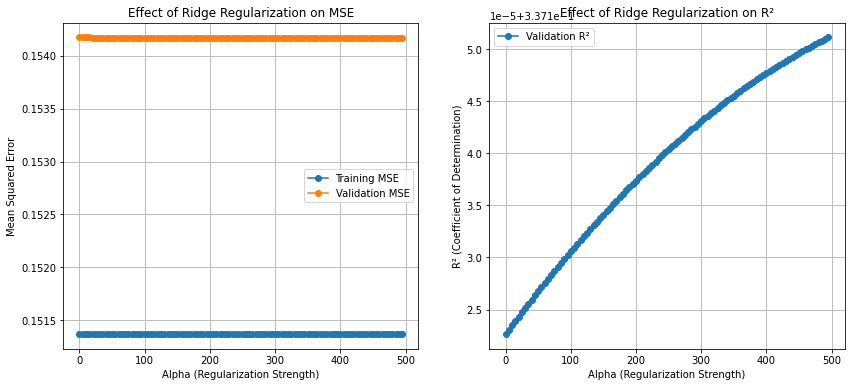

In [18]:
# Step 2: Train-Test Split (80-20)
X3_train, X3_val, y3_train, y3_val = train_test_split(X3, y3, test_size=0.2, random_state=n_number)

# Step 3: Standardize the features (scale to zero mean and unit variance)

scaler = StandardScaler()
X3_train_scaled = scaler.fit_transform(X3_train)
X3_val_scaled = scaler.transform(X3_val)

# Step 4: Train a lasso Regression model with different alpha values
alphas = np.arange(0,2000,5)
ridge_train_mse_3 = []
ridge_val_mse_3 = []
ridge_train_r2_3 = []  # Store R² for training
ridge_val_r2_3 = []    # Store R² for validation

for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)  # Use Ridge Regression instead of Lasso
    ridge_model.fit(X3_train_scaled, y3_train)
    
    # Predict on training and validation data
    y_train_pred_ridge_3 = ridge_model.predict(X3_train_scaled)
    y_val_pred_ridge_3 = ridge_model.predict(X3_val_scaled)
    
    # Compute MSE for training and validation
    ridge_train_mse_3.append(mean_squared_error(y3_train, y_train_pred_ridge_3))
    ridge_val_mse_3.append(mean_squared_error(y3_val, y_val_pred_ridge_3))
    ridge_train_r2_3.append(r2_score(y3_train, y_train_pred_ridge_3))
    ridge_val_r2_3.append(r2_score(y3_val, y_val_pred_ridge_3))

# Find the alpha with the lowest validation MSE
best_alpha_ridge_3 = alphas[np.argmin(ridge_val_mse_3)]
print(f"Best Alpha (Ridge): {best_alpha_ridge_3}")
print(f"Lowest Validation MSE: {min(ridge_val_mse_3)}")

# Step 4: Plot Training and Validation MSE
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(alphas, ridge_train_mse_3, label='Training MSE', marker='o')
plt.plot(alphas, ridge_val_mse_3, label='Validation MSE', marker='o')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Mean Squared Error')
plt.title('Effect of Ridge Regularization on MSE')
plt.legend()
plt.grid(True)

# Plot R²
plt.subplot(1, 2, 2)
# plt.plot(alphas, ridge_train_r2, label='Training R²', marker='o')
plt.plot(alphas, ridge_val_r2_3, label='Validation R²', marker='o')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R² (Coefficient of Determination)')
plt.title('Effect of Ridge Regularization on R²')


plt.legend()
plt.grid(True)
plt.show()

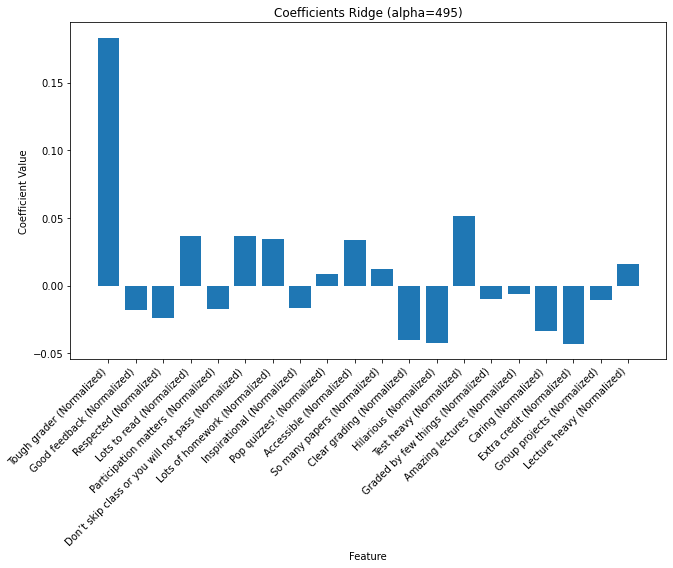

Final Validation R²: 0.3371511392519946
Feature with the highest coefficient (absolute value): Tough grader (Normalized)
Value of the highest coefficient: 0.18322641378350873


In [19]:
# Step 7: Visualize the betas (coefficients) from all models

# Ridge model coefficients (for the best alpha, e.g., alpha=1.0)
ridge_model = Ridge(alpha=best_alpha_ridge_3)
ridge_model.fit(X3_train_scaled, y3_train)
betas_ridge = ridge_model.coef_

# Plot the coefficients (betas) for all models
plt.figure(figsize=(18, 8))

feature_name = [ 'Tough grader (Normalized)',
       'Good feedback (Normalized)', 'Respected (Normalized)',
       'Lots to read (Normalized)', 'Participation matters (Normalized)',
       'Don’t skip class or you will not pass (Normalized)',
       'Lots of homework (Normalized)', 'Inspirational (Normalized)',
       'Pop quizzes! (Normalized)', 'Accessible (Normalized)',
       'So many papers (Normalized)', 'Clear grading (Normalized)',
       'Hilarious (Normalized)', 'Test heavy (Normalized)',
       'Graded by few things (Normalized)', 'Amazing lectures (Normalized)',
       'Caring (Normalized)', 'Extra credit (Normalized)',
       'Group projects (Normalized)', 'Lecture heavy (Normalized)'
      ]

# Ridge Regression Coefficients (for best alpha)
plt.subplot(1, 2, 1)
plt.bar(feature_name, betas_ridge)
plt.title(f'Coefficients Ridge (alpha={best_alpha_ridge_3})')
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')


plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

final_train_r2 = r2_score(y3_train, ridge_model.predict(X3_train_scaled))
final_val_r2 = r2_score(y3_val, ridge_model.predict(X3_val_scaled))

print(f"Final Validation R²: {final_val_r2}")


highest_beta_index = np.argmax(np.abs(betas_ridge))
highest_beta_feature = feature_name[highest_beta_index]
highest_beta_value = betas_ridge[highest_beta_index]

print(f"Feature with the highest coefficient (absolute value): {highest_beta_feature}")
print(f"Value of the highest coefficient: {highest_beta_value}")

Best Alpha (Ridge): 330
Lowest Validation MSE: 0.1645649276346902


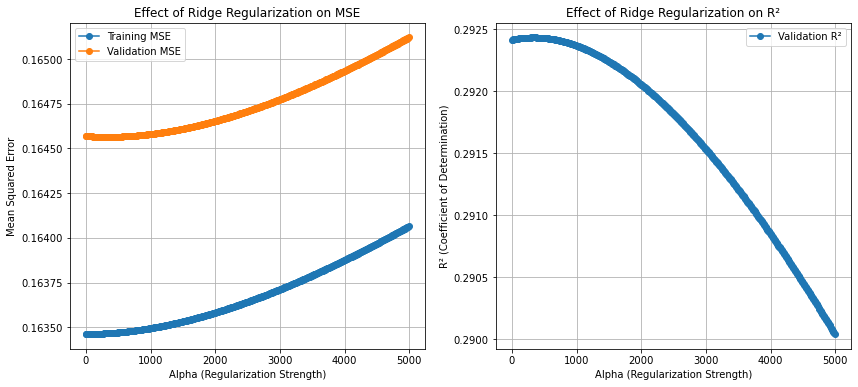

In [20]:
# rerun the code with unnormalized data

# Step 2: Train-Test Split (80-20)
X3_train, X3_val, y3_train, y3_val = train_test_split(X2_origin, y3, test_size=0.2, random_state=n_number)

# Step 3: Standardize the features (scale to zero mean and unit variance)

scaler = StandardScaler()
X3_train_scaled = scaler.fit_transform(X3_train)
X3_val_scaled = scaler.transform(X3_val)

# Step 4: Train a lasso Regression model with different alpha values
# alphas = np.logspace(-3, 1, 100)  # Logarithmic range for alpha
alphas = np.arange(0,5000,10)
ridge_train_mse_3 = []
ridge_val_mse_3 = []
ridge_train_r2_3 = []  # Store R² for training
ridge_val_r2_3 = []    # Store R² for validation

for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)  # Use Ridge Regression instead of Lasso
    ridge_model.fit(X3_train_scaled, y3_train)
    
    # Predict on training and validation data
    y_train_pred_ridge_3 = ridge_model.predict(X3_train_scaled)
    y_val_pred_ridge_3 = ridge_model.predict(X3_val_scaled)
    
    # Compute MSE for training and validation
    ridge_train_mse_3.append(mean_squared_error(y3_train, y_train_pred_ridge_3))
    ridge_val_mse_3.append(mean_squared_error(y3_val, y_val_pred_ridge_3))
    ridge_train_r2_3.append(r2_score(y3_train, y_train_pred_ridge_3))
    ridge_val_r2_3.append(r2_score(y3_val, y_val_pred_ridge_3))

# Find the alpha with the lowest validation MSE
best_alpha_ridge_3 = alphas[np.argmin(ridge_val_mse_3)]
print(f"Best Alpha (Ridge): {best_alpha_ridge_3}")
print(f"Lowest Validation MSE: {min(ridge_val_mse_3)}")

# Step 4: Plot Training and Validation MSE
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(alphas, ridge_train_mse_3, label='Training MSE', marker='o')
plt.plot(alphas, ridge_val_mse_3, label='Validation MSE', marker='o')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Mean Squared Error')
plt.title('Effect of Ridge Regularization on MSE')
plt.legend()
plt.grid(True)

# Plot R²
plt.subplot(1, 2, 2)
# plt.plot(alphas, ridge_train_r2, label='Training R²', marker='o')
plt.plot(alphas, ridge_val_r2_3, label='Validation R²', marker='o')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R² (Coefficient of Determination)')
plt.title('Effect of Ridge Regularization on R²')


plt.legend()
plt.grid(True)
plt.show()

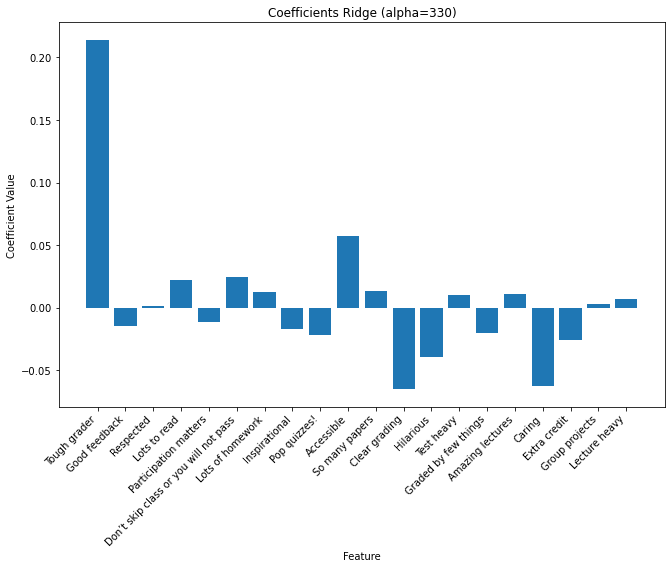

Final Validation R²: 0.2924319885926173
Feature with the highest coefficient (absolute value): Tough grader
Value of the highest coefficient: 0.2140400917159421


In [21]:
# Step 7: Visualize the betas (coefficients) from all models

# Ridge model coefficients (for the best alpha, e.g., alpha=1.0)
ridge_model = Ridge(alpha=best_alpha_ridge_3)
ridge_model.fit(X3_train_scaled, y3_train)
betas_ridge = ridge_model.coef_

# Plot the coefficients (betas) for all models
plt.figure(figsize=(18, 8))

feature_name = ['Tough grader',
       'Good feedback', 'Respected', 'Lots to read', 'Participation matters',
       'Don’t skip class or you will not pass', 'Lots of homework',
       'Inspirational', 'Pop quizzes!', 'Accessible', 'So many papers',
       'Clear grading', 'Hilarious', 'Test heavy', 'Graded by few things',
       'Amazing lectures', 'Caring', 'Extra credit', 'Group projects',
       'Lecture heavy'
      ]

# Ridge Regression Coefficients (for best alpha)
plt.subplot(1, 2, 1)
plt.bar(feature_name, betas_ridge)
plt.title(f'Coefficients Ridge (alpha={best_alpha_ridge_3})')
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')


plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

final_train_r2 = r2_score(y3_train, ridge_model.predict(X3_train_scaled))
final_val_r2 = r2_score(y3_val, ridge_model.predict(X3_val_scaled))

print(f"Final Validation R²: {final_val_r2}")

highest_beta_index = np.argmax(np.abs(betas_ridge))
highest_beta_feature = feature_name[highest_beta_index]
highest_beta_value = betas_ridge[highest_beta_index]

print(f"Feature with the highest coefficient (absolute value): {highest_beta_feature}")
print(f"Value of the highest coefficient: {highest_beta_value}")

### Q10 - Build a classification model that predicts whether a professor receives a “pepper” from all available factors(both tags and numerical). 
Make sure to include model quality metrics such as AU(RO)C and also address class imbalanceconcerns.

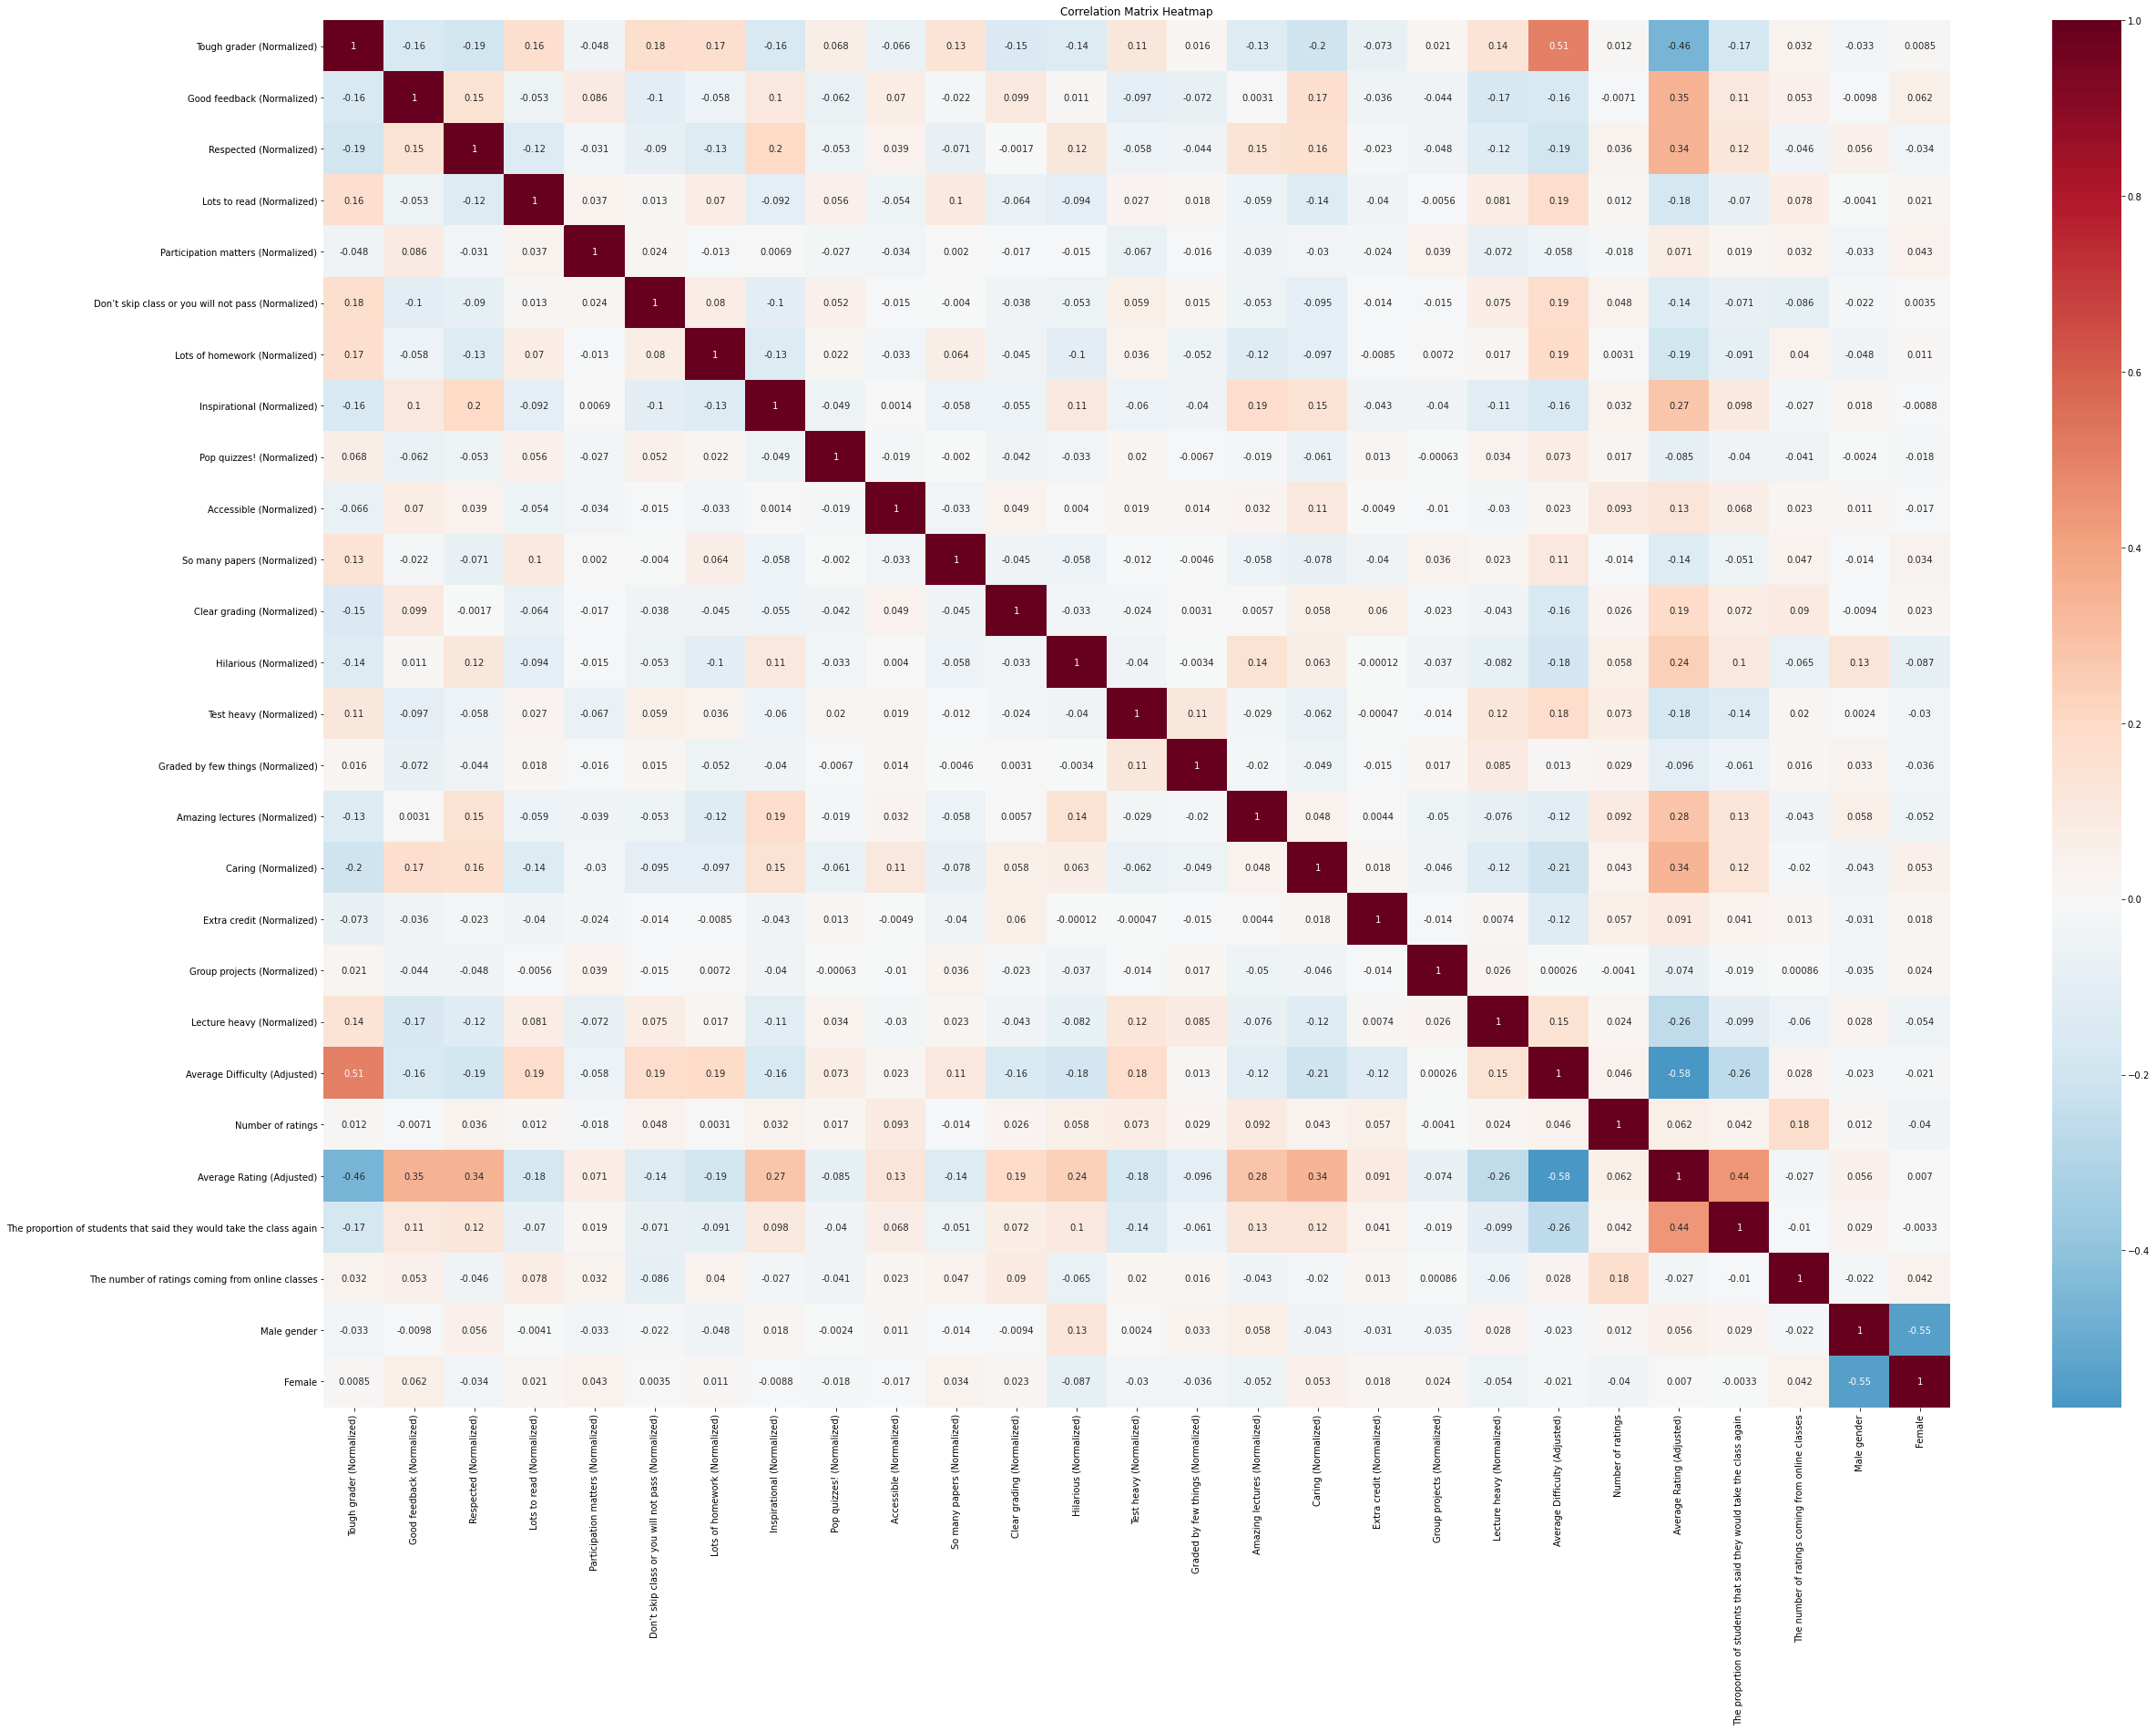

,Tough grader (Normalized),Good feedback (Normalized),Respected (Normalized),Lots to read (Normalized),Participation matters (Normalized),Don’t skip class or you will not pass (Normalized),Lots of homework (Normalized),Inspirational (Normalized),Pop quizzes! (Normalized),Accessible (Normalized),...,Extra credit (Normalized),Group projects (Normalized),Lecture heavy (Normalized),Average Difficulty (Adjusted),Number of ratings,Average Rating (Adjusted),The proportion of students that said they would take the class again,The number of ratings coming from online classes,Male gender,Female
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.0,0.000000,...,0.0,0.000000,0.500000,2.318731,2.0,4.284895,76.417105,0.0,0,1
1,0.500000,0.250000,0.500000,0.250000,0.000000,1.000000,0.500000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,2.941951,4.0,3.460639,76.417105,0.0,1,0
2,0.600000,0.300000,0.000000,0.000000,0.200000,0.400000,0.200000,0.100000,0.0,0.000000,...,0.0,0.100000,0.000000,3.353358,10.0,3.648037,76.417105,0.0,0,0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,3.398414,1.0,3.106119,76.417105,0.0,0,0
4,0.363636,0.590909,0.045455,0.136364,0.090909,0.136364,0.090909,0.045455,0.0,0.136364,...,0.0,0.045455,0.136364,3.247746,22.0,3.536979,56.000000,7.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69984,0.500000,0.000000,0.000000,0.750000,0.000000,0.250000,0.000000,0.250000,0.0,0.000000,...,0.0,0.000000,0.000000,3.399094,4.0,3.860639,76.417105,0.0,0,1
69985,0.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.500000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,2.718731,2.0,3.284895,76.417105,0.0,0,0
69986,0.500000,0.500000,0.000000,0.000000,0.500000,0.500000,0.000000,0.000000,0.0,0.000000,...,0.0,0.000000,0.000000,2.518731,2.0,4.084895,76.417105,0.0,1,0
69987,0.000000,0.500000,0.166667,0.166667,0.333333,0.166667,0.000000,0.000000,0.0,0.166667,...,0.0,0.000000,0.000000,2.088184,6.0,4.602719,100.000000,2.0,1,0


In [22]:
y4 =  df_cleaned['Received a “pepper”?']
X4 = df_cleaned[[ 'Tough grader (Normalized)',
       'Good feedback (Normalized)', 'Respected (Normalized)',
       'Lots to read (Normalized)', 'Participation matters (Normalized)',
       'Don’t skip class or you will not pass (Normalized)',
       'Lots of homework (Normalized)', 'Inspirational (Normalized)',
       'Pop quizzes! (Normalized)', 'Accessible (Normalized)',
       'So many papers (Normalized)', 'Clear grading (Normalized)',
       'Hilarious (Normalized)', 'Test heavy (Normalized)',
       'Graded by few things (Normalized)', 'Amazing lectures (Normalized)',
       'Caring (Normalized)', 'Extra credit (Normalized)',
       'Group projects (Normalized)', 'Lecture heavy (Normalized)','Average Difficulty (Adjusted)', 
       'Number of ratings', 'Average Rating (Adjusted)',
       'The proportion of students that said they would take the class again',
       'The number of ratings coming from online classes', 
       'Male gender',
       'Female'
      ]]

# check correlation
correlation_matrix4 = X4.corr()

plt.figure(figsize=(40, 28))
sns.heatmap(correlation_matrix4, annot=True, cmap="RdBu_r", center=0, xticklabels=True, yticklabels=True)
plt.title('Correlation Matrix Heatmap')
plt.show()
X4

In [23]:
missing_values4 = X4.isna().sum()
print(missing_values4)
len(X4)

Tough grader (Normalized)                                               0
Good feedback (Normalized)                                              0
Respected (Normalized)                                                  0
Lots to read (Normalized)                                               0
Participation matters (Normalized)                                      0
Don’t skip class or you will not pass (Normalized)                      0
Lots of homework (Normalized)                                           0
Inspirational (Normalized)                                              0
Pop quizzes! (Normalized)                                               0
Accessible (Normalized)                                                 0
So many papers (Normalized)                                             0
Clear grading (Normalized)                                              0
Hilarious (Normalized)                                                  0
Test heavy (Normalized)               

69989

Check imbalance: Counter({0.0: 40352, 1.0: 15639})
              precision    recall  f1-score   support

         0.0       0.80      0.92      0.85     10041
         1.0       0.67      0.40      0.50      3957

    accuracy                           0.77     13998
   macro avg       0.73      0.66      0.68     13998
weighted avg       0.76      0.77      0.75     13998

optimal_threshold is 0.3194133946508495
              precision    recall  f1-score   support

         0.0       0.86      0.75      0.80     10041
         1.0       0.53      0.69      0.60      3957

    accuracy                           0.74     13998
   macro avg       0.69      0.72      0.70     13998
weighted avg       0.77      0.74      0.75     13998



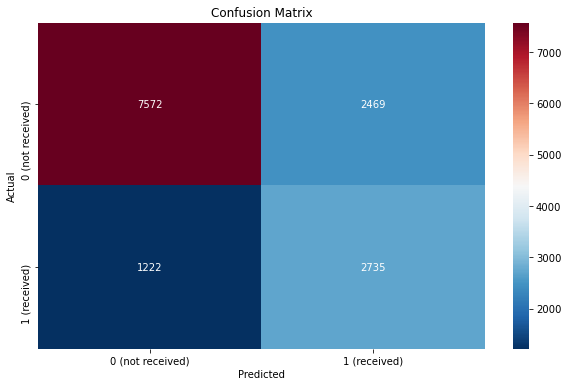

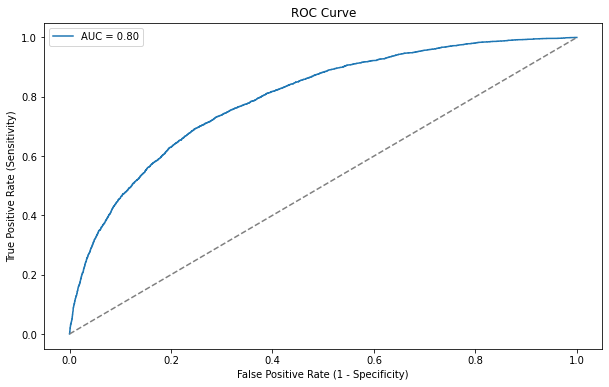

Precision at optimal threshold: 0.5255572636433513
Recall at optimal threshold: 0.6911801870103614


In [24]:
# Train-test split
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=n_number)

X4_train_continuous = X4_train.iloc[:, :25]  
X4_train_others = X4_train.iloc[:, 25:]     

X4_test_continuous = X4_test.iloc[:, :25]     
X4_test_others = X4_test.iloc[:, 25:]        

scaler = StandardScaler()
X4_train_continuous_scaled = scaler.fit_transform(X4_train_continuous)
X4_test_continuous_scaled = scaler.transform(X4_test_continuous)

# Combine the scaled continuous columns with the rest (dummy variables)
X4_train_scaled = np.hstack([X4_train_continuous_scaled, X4_train_others.values])
X4_test_scaled = np.hstack([X4_test_continuous_scaled, X4_test_others.values])

# Fit logistic regression
log_reg = LogisticRegression()
log_reg.fit(X4_train_scaled, y4_train)

print(f'Check imbalance: {Counter(y4_train)}')

# Predictions
y4_pred = log_reg.predict(X4_test_scaled)
y4_prob = log_reg.predict_proba(X4_test_scaled)[:, 1]

# Efficiently create and display the DataFrame
results = pd.DataFrame({'Predictions': y4_pred, 'Probabilities': y4_prob})

THRESHOLD = 0.5 # Revisit later!
# THRESHOLD = optimal_threshold
y4_pred_new = (y4_prob > THRESHOLD).astype(int)

class_report = classification_report(y4_test, y4_pred_new) #y_pred_new
print(class_report)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y4_test, y4_prob)
roc_auc = auc(fpr, tpr)

optimal_threshold_index = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_threshold_index]
print(f"optimal_threshold is {optimal_threshold}")


##-------------------------------------------
THRESHOLD = optimal_threshold 

y4_pred_new = (y4_prob > THRESHOLD).astype(int)

class_report = classification_report(y4_test, y4_pred_new) #y_pred_new
print(class_report)


# Confusion Matrix
plt.figure(figsize=(10, 6))
conf_matrix = confusion_matrix(y4_test, y4_pred_new) #y_pred_new
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="RdBu_r", 
            xticklabels=["0 (not received)", "1 (received)"], 
            yticklabels=["0 (not received)", "1 (received)"])

# Add title and labels
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y4_test, y4_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.legend()
plt.show()

print(f"Precision at optimal threshold: {precision_score(y4_test, y4_pred_new)}")
print(f"Recall at optimal threshold: {recall_score(y4_test, y4_pred_new)}")